# Flow Matching Basics: Data, Models, and Linear Interpolation


This notebook introduces the fundamentals of flow matching for generative modeling. We'll explore how to transform a simple latent distribution into complex target distributions by learning velocity fields along interpolating paths.

## Overview

Flow matching learns to transport samples from a simple source or "noise" distribution $\mu_1$ (like a standard Gaussian) to a complex target distribution $\mu_0$ (our data) by following a time-dependent velocity field $v_t(x)$. The key insight is that we can train a neural network to approximate this velocity field using individual sample pairs.

First we need to set up our environment.


## Setup for Google Colab

In [1]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    print("Installing dependencies...")
    !pip install -q pot geomloss

    # Download fm_utils.py
    import urllib.request
    url = "https://raw.githubusercontent.com/JChemseddine/fm_tutorial/main/fm_utils.py"
    urllib.request.urlretrieve(url, "fm_utils.py")
    print("✓ Setup complete!")
else:
    # Local development - add parent directory to path
    import sys
    sys.path.insert(0, '..')

Installing dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.0/83.0 kB 9.7 MB/s eta 0:00:00
✓ Setup complete!


## Setup and Imports

We begin by importing the necessary libraries and setting up our computational environment. We'll use PyTorch for neural networks and training, and matplotlib for visualization.


In [2]:
import math
import random
from typing import Callable, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.nn.utils import clip_grad_norm_

# Import utilities from fm_utils (also works in Colab after setup)
try:
    from fm_utils import (
        plot_source_target_trajectories,
        make_latent_sampler,
        update_ema,
    )
except ImportError:
    raise ImportError("fm_utils not found. Please ensure fm_utils.py is in the path.")

plt.style.use("seaborn-v0_8")
torch.set_default_dtype(torch.float32)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed: int) -> None:
    """Seed Python, NumPy, and PyTorch for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print(f"Using device: {DEVICE}")

Using device: cuda


## The Flow Matching Objective

Our goal is to learn a velocity field $v_t$ by approximating it with a neural network $v^\theta_t$.

**Task:** Learn $v_t$ via neural network $v^\theta_t$

The ideal loss function would be:
$$
\mathcal{L}(\theta) := \mathbb{E}_{t \sim \mathcal{U}(0,T), x \sim \mu_t} \Big[ \left\| v_t^\theta(x) - v_t(x) \right\|^2 \Big]
$$

However, this is **not accessible** because we don't know $\mu_t$ or $v_t$ in practice.

**Key Idea:** Make it conditional! We can rewrite the loss (up to a constant) as:
$$
\mathcal{L}(\theta) = \mathbb{E}_{t \sim \mathcal{U}(0,T), y \sim \mu_0, x \sim \mu_t(\cdot|y)} \left[ \left\| v_t^\theta(x) - v_t^y(x) \right\|^2 \right]
$$

The conditional velocity fields $v_t^y$ belonging to conditional flows $\mu_t(\cdot|y)$ starting from $\delta_y$ are available in analytic form for certain couplings (e.g., from optimal transport).

**All you need is the conditional $v_t^y$!**

## Target Distributions

To demonstrate flow matching, we'll work with two 2D distributions that showcase different challenges:

1. **Two Moons:** Two interleaving half-circle shapes forming a classic non-linear classification dataset
2. **Grid GMM:** Nine Gaussian components arranged in a 3×3 grid

We define a common interface for these distributions and implement each one with sampling capabilities. These implementations are also available in `fm_utils.py` for use in later notebooks.

In [3]:
class BaseDistribution2D:
    """Minimal interface shared by the toy 2-D distributions."""
    def sample(
        self,
        n: int,
        *,
        device: Optional[torch.device | str] = None,
        dtype: Optional[torch.dtype] = None,
    ) -> torch.Tensor:
        raise NotImplementedError




In [4]:
class TwoMoons(BaseDistribution2D):
    """2D two moons distribution - sample only (no analytic log-prob)."""



    def __init__(self, noise: float = 0.1) -> None:
        self.noise = float(noise)

    def sample(
        self,
        n: int,
        *,
        device: Optional[torch.device | str] = None,
        dtype: Optional[torch.dtype] = None,
    ) -> torch.Tensor:
        device = torch.device(device) if device is not None else DEVICE
        dtype = dtype or torch.get_default_dtype()
        n1 = n // 2
        n2 = n - n1
        # Moon 1: centered at (0,0), radius 1, theta ∈ [0,π]
        theta1 = math.pi * torch.rand(n1, device=device, dtype=dtype)
        x1 = torch.stack([torch.cos(theta1), torch.sin(theta1)], dim=-1)
        # Moon 2: shift/flip to interleave
        theta2 = math.pi * torch.rand(n2, device=device, dtype=dtype)
        x2 = torch.stack([1.0 - torch.cos(theta2), 1.0 - torch.sin(theta2) - 0.5], dim=-1)
        x = torch.cat([x1, x2], dim=0)
        if self.noise > 0:
            x = x + self.noise * torch.randn_like(x)
        return x


class GridGMM9(BaseDistribution2D):
    """Nine-component Gaussian mixture on a 3x3 grid."""



    def __init__(self, spacing: float = 1.0, var: float = 0.01, weights: Optional[list[float]] = None) -> None:
        coords = (-float(spacing), 0.0, float(spacing))
        self.means = torch.tensor([(x, y) for x in coords for y in coords], dtype=torch.get_default_dtype())
        if weights is None:
            weights = [0.01, 0.1, 0.3, 0.2, 0.02, 0.15, 0.02, 0.15, 0.05]
        w = torch.tensor(weights, dtype=torch.get_default_dtype())
        self.weights = (w / w.sum()).tolist()
        self.var = float(var)
        self._log_weights: Optional[torch.Tensor] = None

    def sample(
        self,
        n: int,
        *,
        device: Optional[torch.device | str] = None,
        dtype: Optional[torch.dtype] = None,
    ) -> torch.Tensor:
        device = torch.device(device) if device is not None else DEVICE
        dtype = dtype or torch.get_default_dtype()
        cat = torch.distributions.Categorical(probs=torch.tensor(self.weights, device=device, dtype=dtype))
        idx = cat.sample((n,))
        means = self.means.to(device=device, dtype=dtype)
        noise = torch.randn(n, 2, device=device, dtype=dtype) * math.sqrt(self.var)
        return means[idx] + noise




def get_distribution(name: str, **kwargs) -> BaseDistribution2D:
    """Instantiate one of the benchmark 2D distributions."""
    name_l = name.lower()
    if name_l in {"twomoons", "two_moons"}:
        return TwoMoons(**kwargs)
    if name_l in {"gridgmm", "gridgmm9"}:
        return GridGMM9(**kwargs)
    raise ValueError(f"Unknown distribution '{name}'.")

## The Velocity Network

The core of flow matching is a neural network that predicts velocity fields conditioned on both spatial position $x$ and time $t$. We use a residual MLP with sinusoidal time embeddings, which provides the network with a rich representation of the time variable.

The architecture consists of:
- **Sinusoidal time embedding:** Maps scalar time to high-dimensional features
- **Input projection:** Projects spatial coordinates to hidden dimension
- **Residual blocks:** Process features while conditioning on time
- **Output layer:** Predicts velocity in the same space as input


In [5]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, embed_dim: int, max_freq: float = 1000.0) -> None:
        super().__init__()
        half = embed_dim // 2
        freq = torch.logspace(0, math.log10(max_freq), steps=half)
        self.register_buffer("freq", freq)

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        t = t.view(-1, 1).float()
        angles = t * self.freq.view(1, -1)
        return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)


class VelocityMLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 2,
        hidden_dim: int = 64,
        time_embed_dim: int = 64,
        num_layers: int = 3,
    ) -> None:
        super().__init__()
        self.time_embed = SinusoidalTimeEmbedding(time_embed_dim)

        # Build simple feedforward network
        layers = []
        layers.append(nn.Linear(input_dim + time_embed_dim, hidden_dim))
        layers.append(nn.SiLU())

        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.SiLU())

        layers.append(nn.Linear(hidden_dim, input_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        if t.dim() == 1:
            t = t.unsqueeze(-1)
        t_emb = self.time_embed(t)
        if t_emb.shape[0] == 1 and x.shape[0] > 1:
            t_emb = t_emb.expand(x.shape[0], -1)

        h = torch.cat([x, t_emb], dim=-1)
        return self.net(h)


## Visualization and Utility Functions

We import several utility functions from `fm_utils.py`:
- `make_latent_sampler`: Creates samplers for different latent distributions (gaussian, uniform, student_t)
- `update_ema`: Exponential moving average update for model parameters
- `plot_source_target_trajectories`: Visualization of flow trajectories

We also define simple plotting helpers for this notebook.

In [6]:
def draw_samples(distribution: BaseDistribution2D, n: int = 4096) -> torch.Tensor:
    """Sample from a distribution and return on CPU."""
    samples = distribution.sample(n, device=DEVICE, dtype=torch.float32)
    return samples.detach().cpu()


def plot_points(ax, samples: torch.Tensor, title: str, color: str, *, alpha: float = 0.6) -> None:
    """Simple scatter plot helper for 2D samples with automatic axis limits."""
    pts = samples.detach().cpu().numpy()
    ax.scatter(pts[:, 0], pts[:, 1], s=6, alpha=alpha, color=color, linewidths=0)
    ax.set_title(title)

    # Compute axis limits with some padding
    x_min, x_max = pts[:, 0].min(), pts[:, 0].max()
    y_min, y_max = pts[:, 1].min(), pts[:, 1].max()
    x_range = x_max - x_min
    y_range = y_max - y_min
    padding = 0.1

    ax.set_xlim(x_min - padding * x_range, x_max + padding * x_range)
    ax.set_ylim(y_min - padding * y_range, y_max + padding * y_range)
    ax.set_aspect('equal', 'box')


## Visualizing the Target Distributions

Let's sample from each of our target distributions to see what we're trying to model. These visualizations show the different challenges: disconnected regions, multiple modes, and varying density.


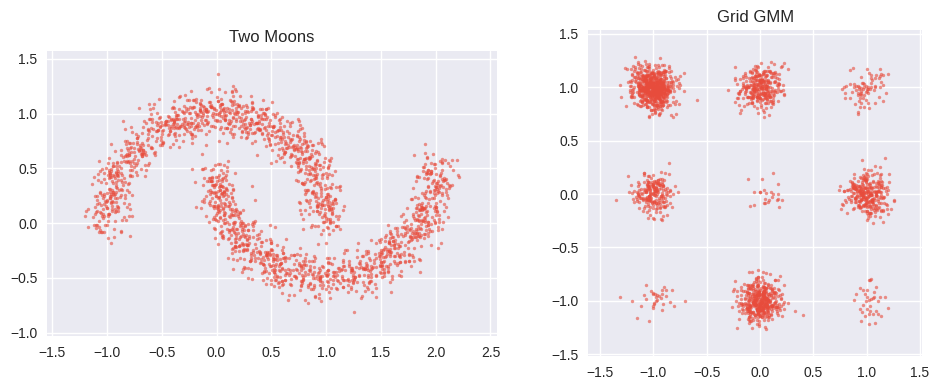

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Two Moons
two_moons = get_distribution("twomoons")
pts = draw_samples(two_moons, n=2048)
plot_points(axes[0], pts, "Two Moons", "#E74C3C")

# Grid GMM
grid_gmm = get_distribution("gridgmm")
pts = draw_samples(grid_gmm, n=2048)
plot_points(axes[1], pts, "Grid GMM", "#E74C3C")

plt.tight_layout()
plt.show()

## Training with Linear Interpolation

### From Theory to Practice

In generative modeling, we start with a simple latent distribution $\mu_0$, choose a target data distribution $\mu_1$, and consider an interpolating curve of measures $\mu_t$ with a velocity field $v_t$.

The evolution $t \mapsto \mu_t$ is governed by the **continuity equation**:
$
\partial_t \mu_t + \nabla_x \cdot (\mu_t v_t) = 0
$

Intuitively, $\mu_t$ describes how mass is distributed at time $t$, and $v_t(x)$ tells us in which direction points at $x$ are moving. Although solving this PDE directly is challenging, we can approximate the velocity field with a neural network.

### Straight-Line Interpolation

The simplest approach is to connect a data sample $x_0$ and a latent sample $x_1$ with a straight line:
$
x_t = (1 - t) x_0 + t x_1, \quad t \in [0, 1]
$

The time derivative of this path is:
$
\frac{\mathrm{d}}{\mathrm{d}t} x_t = x_1 - x_0
$

For a conditional flow starting at $x_0$ and ending at $y = x_1$, the conditional velocity field is:
$
v_t^y(x) = \frac{y - x}{1 - t}
$

When evaluated along our straight line (where $x = x_t$ and $y = x_1$), this simplifies to $x_1 - x_0$.

### Training Objective

We train the network $v_t^\theta$ by minimizing:
$
\mathbb{E}_{t, x_0, x_1} \left[ \| v_t^\theta(t, x_t) - (x_1 - x_0) \|^2 \right]
$

where $x_0 \sim \mu_0$ (data), $x_1 \sim \mu_1$ (latent), $t \sim \mathcal{U}(0,1)$, and $x_t = (1-t)x_0 + tx_1$.

This is the simplest form of flow matching, using independent random pairings between data and latent samples.


### Configuration and Training Setup

We define a simple configuration dictionary to organize our hyperparameters and a training function that returns results in a dictionary.

**🎯 Exercise 1: Complete the training loop**

Before running the training, you'll need to complete the `train_linear_flow` function below. Fill in the 5 TODO sections:
1. Sample random time `t`
2. Compute interpolated point `x_t`
3. Compute target velocity
4. Predict velocity with the model
5. Compute the loss

Refer to the theory section above for the mathematical formulas!

In [8]:
def train_linear_flow(config):
    """Train a flow matching model with linear interpolation."""
    set_seed(config['seed'])
    sampler = get_distribution(config['target_name'])
    model = VelocityMLP(input_dim=config['dim']).to(DEVICE)
    ema_model = VelocityMLP(input_dim=config['dim']).to(DEVICE)
    ema_model.load_state_dict(model.state_dict())
    latent_sampler = make_latent_sampler(config['latent_name'], DEVICE, config['dim'])

    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])
    losses = []

    for step in range(config['steps']):
        # Sample x0 from data and x1 from latent
        x0 = sampler.sample(config['batch_size'], device=DEVICE, dtype=torch.float32)
        if x0.dim() > 2:
            x0 = x0.view(x0.shape[0], -1)
        x1 = latent_sampler((config['batch_size'], config['dim']))

        t = torch.rand(config['batch_size'], 1, device=DEVICE)

        x_t = (1 - t) * x0 + t * x1

        velocity_target = x1 - x0

        pred = model(t, x_t)

        loss = ((pred - velocity_target) ** 2).mean()

        optimizer.zero_grad()
        loss.backward()
        clip_grad_norm_(model.parameters(), config['grad_clip'])
        optimizer.step()
        update_ema(ema_model, model, config.get('ema_decay', 0.9))

        losses.append(loss.detach().cpu().item())
        if (step + 1) % config['log_every'] == 0:
            print(f"step {step + 1:5d} | loss = {losses[-1]:.6f}")

    return {
        'config': config,
        'sampler': sampler,
        'model': model,
        'ema': ema_model,
        'losses': losses,
        'latent_sampler': latent_sampler,
    }

### Running a Training Session

Let's train a flow matching model on a target distribution. You can choose either:
- `'gridgmm'` - Nine Gaussian components in a 3×3 grid (multi-modal)
- `'twomoons'` - Two interleaving half-circles (non-linear manifold)

Try both to see how the model performs on different distribution types!

In [9]:
config = {
    'target_name': 'twomoons',  # Options: 'gridgmm' or 'twomoons'
    'latent_name': 'gaussian',  # Options: 'gaussian', 'uniform', or 'student_t'
    'dim': 2,
    'flow_T': 1.0,
    'seed': 7,
    'lr': 1e-3,
    'batch_size': 128,
    'steps': 20_000,
    'log_every': 500,
    'grad_clip': 1.0,
}

run = train_linear_flow(config)

step   500 | loss = 1.011845
step  1000 | loss = 1.028259
step  1500 | loss = 1.197317
step  2000 | loss = 0.961051
step  2500 | loss = 1.030494
step  3000 | loss = 1.174816
step  3500 | loss = 1.001641
step  4000 | loss = 0.871935
step  4500 | loss = 0.862420
step  5000 | loss = 1.043036
step  5500 | loss = 1.070156
step  6000 | loss = 1.088325
step  6500 | loss = 0.762703
step  7000 | loss = 1.018016
step  7500 | loss = 0.974842
step  8000 | loss = 0.874008
step  8500 | loss = 0.952883
step  9000 | loss = 1.011540
step  9500 | loss = 0.891557
step 10000 | loss = 1.036504
step 10500 | loss = 1.012377
step 11000 | loss = 1.045165
step 11500 | loss = 1.022516
step 12000 | loss = 1.036978
step 12500 | loss = 0.982777
step 13000 | loss = 1.101247
step 13500 | loss = 0.922990
step 14000 | loss = 0.811078
step 14500 | loss = 1.101287
step 15000 | loss = 0.923776
step 15500 | loss = 1.100841
step 16000 | loss = 0.918556
step 16500 | loss = 0.913398
step 17000 | loss = 0.964380
step 17500 | l

### Training Loss

Let us plot the MSE Loss during training. We can see it rapidly decreases in the beginning, although it doesn't continue to do so the model performance improves. Therefore training loss does not directly imply sampling performance as you can try out yourself by changing the number of training steps and evaluating the model.


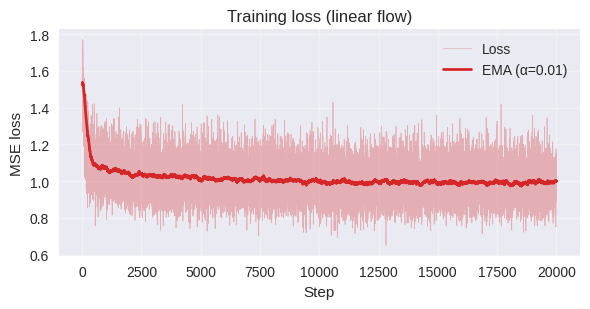

In [10]:
def compute_ema(values, alpha=0.05):
    """Compute exponential moving average with given smoothing factor."""
    ema = [values[0]]
    for val in values[1:]:
        ema.append(alpha * val + (1 - alpha) * ema[-1])
    return ema

fig, ax = plt.subplots(figsize=(6, 3.2))
losses = run['losses']
losses_ema = compute_ema(losses, alpha=0.01)

ax.plot(losses, color="#D62728", alpha=0.3, linewidth=0.5, label='Loss')
ax.plot(losses_ema, color="#D62728", linewidth=2, label='EMA (α=0.01)')
ax.set_xlabel("Step")
ax.set_ylabel("MSE loss")
ax.set_title("Training loss (linear flow)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Note on EMA (Exponential Moving Average):** You might have noticed in the training loop that we maintain an EMA version of the network weights, updated at each step as:

$$\theta_{\text{EMA}} \leftarrow \beta \cdot \theta_{\text{EMA}} + (1 - \beta) \cdot \theta$$

This is motivated by the noisy training loss - the EMA network provides a smoothed, more stable version of the model. Both `run['model']` and `run['ema']` can be used identically (same inputs/outputs), but we typically use the EMA version for evaluation and sampling as it tends to generalize better.

## Sampling from the Learned Flow

### ODE Integration

Once trained, we generate samples by integrating the learned velocity field. Starting from a latent point $z_0$ at time $t=1$, we integrate backwards to $t=0$ following:
$
\frac{\mathrm{d}}{\mathrm{d}t} x(t) = v_t^\theta(t, x(t))
$

We use a simple Euler method:
1. Create a time grid from $T$ down to $0$
2. For each step $\Delta t$, update $x \leftarrow x + \Delta t \cdot v_t^\theta(t, x)$

**🎯 Exercise 2: Complete the Euler integration**

The function below implements this integration. Fill in the 2 TODO sections to complete the ODE solver.

In [11]:
def euler_integrate(
    model: nn.Module,
    z0: torch.Tensor,
    flow_T: float,
    *,
    steps: int = 120,
    return_path: bool = False,
) -> torch.Tensor:
    """
    Integrate the learned velocity field using Euler method.

    Starting from latent z0 at time T, integrate backwards to time 0:
        dx/dt = v_t(x)  =>  x_{t+dt} ≈ x_t + dt * v_t(x_t)

    Args:
        model: Trained velocity network
        z0: Initial latent samples (batch_size, dim)
        flow_T: Total flow time (usually 1.0)
        steps: Number of integration steps
        return_path: If True, return full trajectory

    Returns:
        Final samples at t=0 (or full trajectory if return_path=True)
    """
    times = torch.linspace(flow_T, 0.0, steps, device=z0.device)
    x = z0
    if return_path:
        states = [x]

    for i in range(len(times) - 1):
        t_curr = times[i].expand(z0.shape[0], 1)
        dt = times[i + 1] - times[i]

        velocity = model(t_curr, x)

        x = x + dt * velocity

        if return_path:
            states.append(x)

    if return_path:
        return torch.stack(states, dim=0)
    return x

### Comparing Generated and Target Samples

Let's compare samples from the target distribution with samples generated by our trained model. We also show the latent distribution to visualize the full transformation.


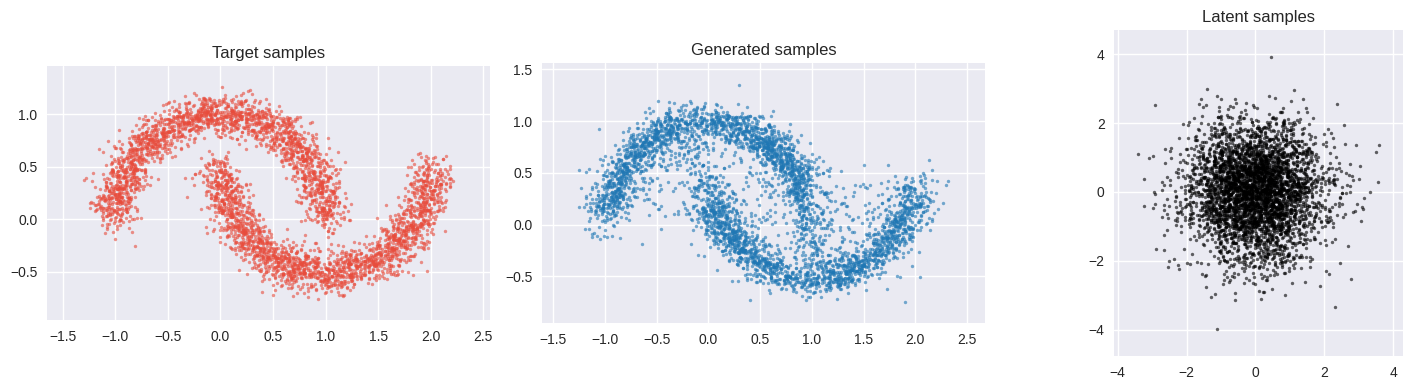

In [12]:
real_samples = draw_samples(run['sampler'], n=4096)
latents_eval = run['latent_sampler']((4096, run['config']['dim']))
with torch.no_grad():
    generated = euler_integrate(run['ema'], latents_eval, run['config']['flow_T'], steps=50)

generated_cpu = generated.detach().cpu()
latents_cpu = latents_eval.detach().cpu()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_points(axes[0], real_samples, 'Target samples', '#E74C3C')
plot_points(axes[1], generated_cpu, 'Generated samples', '#1f77b4')
plot_points(axes[2], latents_cpu, 'Latent samples', '#000000')
plt.tight_layout()
plt.show()

### Visualizing Flow Trajectories

To understand how the flow transforms latent samples into data, we can visualize the complete trajectories. Each curve shows how a single latent point travels through space over time to reach its final position.


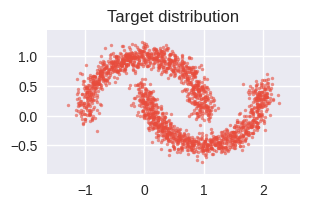

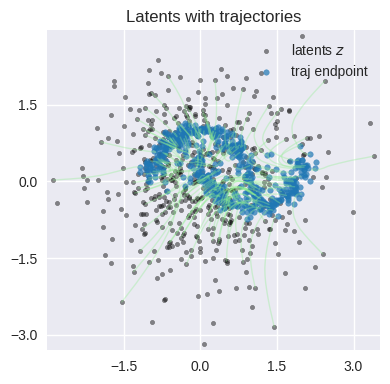

In [13]:
latents_plot = run['latent_sampler']((512, run['config']['dim']))
target_samples = draw_samples(run['sampler'], n=2048)

fig, ax = plt.subplots(figsize=(3, 3))
plot_points(ax, target_samples, 'Target distribution', '#E74C3C')
plt.tight_layout()
plt.show()

with torch.no_grad():
    trajectory_stack = euler_integrate(
        run['ema'],
        latents_plot,
        run['config']['flow_T'],
        steps=60,
        return_path=True,
    )

fig, ax = plt.subplots(figsize=(4, 4))
plot_source_target_trajectories(
    source=latents_plot,
    trajectories=trajectory_stack,
    target=trajectory_stack[-1],
    background=None,
    title='Latents with trajectories',
    ax=ax,

)
plt.tight_layout()
plt.show()

## Summary

In this notebook, we've covered the fundamentals of flow matching:

1. **The conditional flow matching objective:** We showed how to make the intractable marginal flow matching loss tractable by conditioning on target samples

2. **Straight-line interpolation:** The simplest coupling uses $x_t = (1-t)x_0 + tx_1$, giving us the analytic target velocity $v_t = x_1 - x_0$

3. **Neural velocity networks:** Time-conditioned MLPs with sinusoidal embeddings effectively learn the velocity field

4. **ODE integration for sampling:** Once trained, we generate samples by integrating the learned velocity field backwards from latent to data

### What's Next?

This baseline approach uses random pairings between latent and data samples. In the next notebook, we'll explore:
**Optimal transport pairings**
